# Geospatial Data Abstraction Library (GDAL) projects

## 1)	Urban Heat Island Analysis with Landsat 8 (Luxembourg City)

### Goal:
Compute Land Surface Temperature (LST) across an urban area and visualize “hot spots”.

### Data:
- Landsat 8 Collection 2 Level-1 (bands 10: thermal infrared) from GEE
- A shapefile of Luxembourg city boundary

### Steps:
1.	Download & unzip the Landsat scene.
2.	Load city boundary and reproject to the scene CRS.
3.	Clip the thermal band (Band 10) to the city extent.
4.	Convert DN to radiance and then to brightness temperature (Kelvin) using the metadata.
5.	Apply emissivity correction (e.g. using NDVI-based method).
6.	Save the LST raster as GeoTIFF and plot a heat map.

In [2]:
import geopandas as gpd

# Load the shapefile (point to the .shp)
gdf = gpd.read_file('dataset/gadm41_LUX_shp/gadm41_LUX_3.shp')

gdf

C:\Users\duc.tran\Anaconda3\envs\gdalenv\lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect GDAL data files.  Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


,GID_3,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,GID_2,NAME_2,NL_NAME_2,NAME_3,VARNAME_3,NL_NAME_3,TYPE_3,ENGTYPE_3,CC_3,HASC_3,geometry
0,LUX.1.1.1_1,LUX,Luxembourg,LUX.1_1,Diekirch,NA,LUX.1.1_1,Clervaux,NA,Clervaux,NA,NA,Commune,Commune,NA,NA,"POLYGON ((6.11368 50.06501, 6.11385 50.06416, ..."
1,LUX.1.1.3_1,LUX,Luxembourg,LUX.1_1,Diekirch,NA,LUX.1.1_1,Clervaux,NA,Heinerscheid,NA,NA,Commune,Commune,NA,NA,"POLYGON ((6.12228 50.13591, 6.12797 50.13428, ..."
2,LUX.1.1.9_1,LUX,Luxembourg,LUX.1_1,Diekirch,NA,LUX.1.1_1,Clervaux,NA,Parc Hosingen,NA,NA,Commune,Commune,NA,NA,"POLYGON ((6.11301 50.05866, 6.11307 50.05859, ..."
3,LUX.1.1.6_1,LUX,Luxembourg,LUX.1_1,Diekirch,NA,LUX.1.1_1,Clervaux,NA,Troisvierges,NA,NA,Commune,Commune,NA,NA,"POLYGON ((6.02652 50.17767, 6.03136 50.16563, ..."
4,LUX.1.1.7_1,LUX,Luxembourg,LUX.1_1,Diekirch,NA,LUX.1.1_1,Clervaux,NA,Weiswampach,NA,NA,Commune,Commune,NA,NA,"POLYGON ((6.05883 50.15779, 6.06041 50.15745, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,LUX.3.4.6_1,LUX,Luxembourg,LUX.3_1,Luxembourg,NA,LUX.3.4_1,Mersch,NA,Larochette,NA,NA,Commune,Commune,NA,NA,"POLYGON ((6.19869 49.80204, 6.20579 49.79696, ..."
98,LUX.3.4.7_1,LUX,Luxembourg,LUX.3_1,Luxembourg,NA,LUX.3.4_1,Mersch,NA,Lintgen,NA,NA,Commune,Commune,NA,NA,"POLYGON ((6.16438 49.74745, 6.16583 49.74776, ..."
99,LUX.3.4.8_1,LUX,Luxembourg,LUX.3_1,Luxembourg,NA,LUX.3.4_1,Mersch,NA,Lorentzweiler,NA,NA,Commune,Commune,NA,NA,"POLYGON ((6.18464 49.71807, 6.18311 49.71456, ..."
100,LUX.3.4.9_1,LUX,Luxembourg,LUX.3_1,Luxembourg,NA,LUX.3.4_1,Mersch,NA,Mersch,NA,NA,Commune,Commune,NA,NA,"POLYGON ((6.08576 49.69769, 6.08412 49.69739, ..."


In [3]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   GID_3      102 non-null    object  
 1   GID_0      102 non-null    object  
 2   COUNTRY    102 non-null    object  
 3   GID_1      102 non-null    object  
 4   NAME_1     102 non-null    object  
 5   NL_NAME_1  102 non-null    object  
 6   GID_2      102 non-null    object  
 7   NAME_2     102 non-null    object  
 8   NL_NAME_2  102 non-null    object  
 9   NAME_3     102 non-null    object  
 10  VARNAME_3  102 non-null    object  
 11  NL_NAME_3  102 non-null    object  
 12  TYPE_3     102 non-null    object  
 13  ENGTYPE_3  102 non-null    object  
 14  CC_3       102 non-null    object  
 15  HASC_3     102 non-null    object  
 16  geometry   102 non-null    geometry
dtypes: geometry(1), object(16)
memory usage: 13.7+ KB


In [4]:
gdf.describe()

,GID_3,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,GID_2,NAME_2,NL_NAME_2,NAME_3,VARNAME_3,NL_NAME_3,TYPE_3,ENGTYPE_3,CC_3,HASC_3,geometry
count,102,102,102,102,102,102,102,102,102,102,102,102,102,102,102,102,102
unique,102,1,1,3,3,1,12,12,1,102,1,1,1,1,1,1,102
top,LUX.1.1.1_1,LUX,Luxembourg,LUX.3_1,Luxembourg,NA,LUX.3.2_1,Esch-sur-Alzette,NA,Clervaux,NA,NA,Commune,Commune,NA,NA,"POLYGON ((6.113677449000079 50.06501376000017,..."
freq,1,102,102,43,43,102,14,14,102,1,102,102,102,102,102,102,1


In [5]:
#Check CRS and bounds
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [6]:
gdf.total_bounds

array([ 5.74414015, 49.44780731,  6.53077459, 50.18162155])

<Axes: >

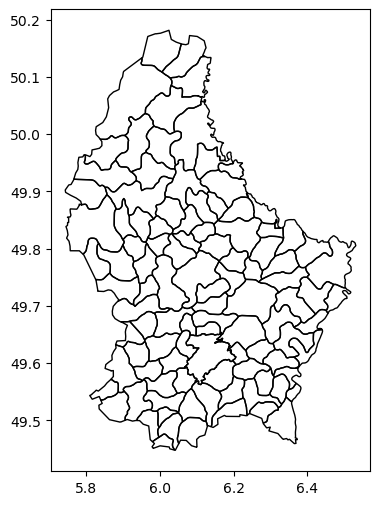

In [7]:
# Plot the geometry
gdf.plot(figsize=(6,6), edgecolor='black', facecolor='none')

In [8]:
gdf['NAME_3'].unique()

array(['Clervaux', 'Heinerscheid', 'Parc Hosingen', 'Troisvierges',
       'Weiswampach', 'Wincrange', 'Bettendorf', 'Bourscheid', 'Diekirch',
       'Erpeldange', 'Ettelbruck', 'Feulen', 'Mertzig', 'Reisdorf',
       'Schieren', "Vallée de l'Ernz", 'Beckerich', 'Ell', 'Grosbous',
       'Préizerdaul', 'Rambrouch', 'Redange', 'Saeul', 'Useldange',
       'Vichten', 'Wahl', 'Putscheid', 'Tandel', 'Vianden', 'Boulaide',
       'Esch-sur-Sûre', 'Goesdorf', 'Kiischpelt', 'Lac de la Haute-Sûre',
       'Wiltz', 'Winseler', 'Beaufort', 'Bech', 'Berdorf', 'Consdorf',
       'Echternach', 'Rosport-Mompach', 'Waldbillig', 'Betzdorf', 'Biwer',
       'Flaxweiler', 'Grevenmacher', 'Junglinster', 'Manternach',
       'Mertert', 'Wormeldange', 'Bous', 'Dalheim', 'Lenningen',
       'Mondorf-les-Bains', 'Remich', 'Schengen', 'Stadtbredimus',
       'Waldbredimus', 'Dippach', 'Garnich', 'Kehlen', 'Koerich',
       'Kopstal', 'Mamer', 'Steinfort', 'NA', 'Bettembourg',
       'Differdange', 'Dudelange'

In [10]:
# Acquiring Landsat 8 thermal data
import ee
import geopandas as gpd
import numpy as np

# Initialize EE
ee.Initialize(project='firstproject-459415')

# Load the local shapefile of Luxembourg's boundary via geopandas
lux_df = gpd.read_file('dataset/gadm41_LUX_shp/gadm41_LUX_3.shp')
#Filter to just Luxembourg city, 'NAME_3 = Luxembourg'
lc = lux_df[lux_df['NAME_3'] == 'Luxembourg']
lc

,GID_3,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,GID_2,NAME_2,NL_NAME_2,NAME_3,VARNAME_3,NL_NAME_3,TYPE_3,ENGTYPE_3,CC_3,HASC_3,geometry
84,LUX.3.3.4_1,LUX,Luxembourg,LUX.3_1,Luxembourg,NA,LUX.3.3_1,Luxembourg,NA,Luxembourg,NA,NA,Commune,Commune,NA,NA,"POLYGON ((6.09676 49.56799, 6.09643 49.56855, ..."


<class 'geopandas.geodataframe.GeoDataFrame'>
<class 'shapely.geometry.polygon.Polygon'>


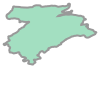

In [11]:
# Grab Lux city geometry directly (as a shapely polygon or multipolygon)
lc_geom = lc.geometry.iloc[0]
print(type(lc))
print(type(lc_geom))
lc_geom

In [56]:
# Convert to GeoJSON dict for EE
lux_geom = ee.Geometry(lc_geom.__geo_interface__)

lux_geom now is only the boundary of Luxembourg city

In [13]:
# Build a filtered Landsat 8 ImageCollection
l8 = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .filterBounds(lux_geom)
    .filterDate('2023-06-01', '2023-08-31')
    .filter(ee.Filter.lt('CLOUD_COVER', 10))
)

# Select the surface temperature band (ST_B10) and take the median
thermal = l8.select('ST_B10').median()

# Clip the thermal image to Luxembourg city
clipped = thermal.clip(lux_geom)

# Export to Drive
task = ee.batch.Export.image.toDrive(
    image = clipped,
    description='Lux_L8_ST_B10_median',
    folder='EarthEngine',
    fileNamePrefix='LUX_L8_ST_B10_median',
    scale=30,
    crs = 'EPSG:4326',
    maxPixels=1e13
)
task.start()
print('Export task started.')

Export task started.


In [24]:
from osgeo import gdal, gdal_array

ds = gdal.Open('dataset/LUX_L8_ST_B10_median.tif')
band = ds.GetRasterBand(1)

print("Data Type:", gdal.GetDataTypeName(band.DataType))

print("Scale:", band.GetScale(), "Offset:", band.GetOffset())

print("Unit Type:", band.GetUnitType())

stats = band.GetStatistics(True, True)
print("Stats (min, max, mean, std):", stats)

Data Type: Float64
Scale: None Offset: None
Unit Type: 
Stats (min, max, mean, std): [43426.0, 49937.5, 46251.50677676801, 1356.0382057494107]


The raw band is unsigned 16-bit integers, and the extreme values (min = 0, max ≈ 50596) show that GEE has exported the “ST_B10” band scaled by a factor (not raw Kelvin).

Landsat Level-2 products are written as scaled integers to allow us to convert the data from floating point to integer for delivery.  In most cases these are written to a 16-bit integer, which saves disk space and provides faster download times.   

Each floating point pixel has an offset applied and then multiplied by a gain to bring the value into the 16-bit integer (or unsigned integer) range.  These values are referred to as scaled integers.  To allow the user to get the data back to its original floating point value, a scale factor and offset are provided for each band.  The scale_factor should be applied to each pixel and then the offset added (i.e. Digital Number (DN) * scale_factor + offset).

Source: https://www.usgs.gov/faqs/how-do-i-use-a-scale-factor-landsat-level-2-science-products

According to the Earth Engine Collection-2 migration guide, the ST_B10 band values are stored as 16-bit integers that need to be scaled and offset to get Kelvin. The recommended conversion is: T_B(K) = DNx0.00341802+149.0

In [18]:
from osgeo import gdal, gdal_array
import numpy as np

# Read the raw DN array
ds = gdal.Open('dataset/LUX_L8_ST_B10_median.tif')
arr = gdal_array.DatasetReadAsArray(ds).astype(float)

# Mask out the zero pixels
print(np.size(arr[arr == 0]))
arr[arr == 0] = np.nan

# Convert to Kelvin
bt = arr * 0.00341802 + 149.0

# Quick statistics to verify plausible temperatures (250–330 K)
print("Min:", np.nanmin(bt), "Max:", np.nanmax(bt), "Mean:", np.nanmean(bt))

0
Min: 295.96289693 Max: 321.93813992 Mean: 306.591825550817


# Apply emissivity correction (e.g. using NDVI-based method).

In [17]:
# Acquire & load Red (B4) and NIR (B5) bands

# Select the surface reflectance bands (SR_B4 and SR_B5) and take the median image
reflectance1 = l8.select('SR_B4').median()
reflectance2 = l8.select('SR_B5').median()

# Clip the thermal image to Luxembourg city
clipped1 = reflectance1.clip(lux_geom)
clipped2 = reflectance2.clip(lux_geom)

# Visualize in the EE code editor or export to Drive
task1 = ee.batch.Export.image.toDrive(
    image = clipped1,
    description='Lux_L8_SR_B4_median',
    folder='EarthEngine',
    fileNamePrefix='LUX_L8_SR_B4_median',
    scale=30,
    crs = 'EPSG:4326',
    maxPixels=1e13
)
task1.start()

task2 = ee.batch.Export.image.toDrive(
    image = clipped2,
    description='Lux_L8_SR_B5_median',
    folder='EarthEngine',
    fileNamePrefix='LUX_L8_SR_B5_median',
    scale=30,
    crs = 'EPSG:4326',
    maxPixels=1e13
)
task2.start()

print('Export tasks started.')

Export tasks started.


For Collection 2 surface-reflectance bands (SR_B*), Google Earth Engine applies a scale factor of 2.75 × 10⁻⁵ and an additive offset of –0.2 to the raw DN values (Collection 1 used a 0.0001 scale with no offset)

In [19]:
def read_tif(path):
    ds = gdal.Open(path)
    arr = gdal_array.DatasetReadAsArray(ds).astype(float)
    return arr, ds.GetGeoTransform(), ds.GetProjection()

# Brightness temperature (Kelvin)
bt, gt, proj = read_tif('dataset/LUX_L8_ST_B10_median.tif')
bt = bt * 0.00341802 + 149.0    # apply EE scale + offset

# Surface reflectance bands (divide by 1e4 if needed)
red, _, _ = read_tif('dataset/LUX_L8_SR_B4_median.tif')
red = red*0.0000275 - 0.2
nir, _, _ = read_tif('dataset/LUX_L8_SR_B5_median.tif')
nir = nir*0.0000275 - 0.2

### Compute NDVI & Emissivity

In [20]:
# NDVI
ndvi = (nir - red) / (nir + red + 1e-6)

# Emissivity ε (simple two‐threshold model)
em = np.where(
    ndvi < 0.2, 
    0.97, 
    np.where(
        ndvi > 0.5,
        0.99,
        0.97 + ((ndvi - 0.2) * (0.99 - 0.97) / (0.5 - 0.2))
    )
)

### Apply Emissivity Correction to BT → LST

LST = T_B/( 1 + ({\lambda T_B}/{\rho}) * ln(em) )

where
- \lambda = 11.5 x 10^{-6} m (Landsat 8 TIRS)
- \rho = 1.438 x 10^{-2} mK

In [21]:
wavelength = 11.5e-6
rho = 1.438e-2

lst = bt / (1 + (wavelength * bt / rho) * np.log(em))

## Save the LST GeoTIFF

In [22]:
# Setup output raster
rows, cols = lst.shape
driver = gdal.GetDriverByName('GTiff')
out_ds = driver.Create('dataset/LUX_L8_LST_median.tif', cols, rows, 1, gdal.GDT_Float32)
out_ds.SetGeoTransform(gt)
out_ds.SetProjection(proj)
out_ds.GetRasterBand(1).WriteArray(lst)

# 5. Flush & close
out_ds.FlushCache()
out_ds = None

print("LST GeoTIFF written: LUX_L8_LST_median.tif")

LST GeoTIFF written: LUX_L8_LST_median.tif


# Visualize

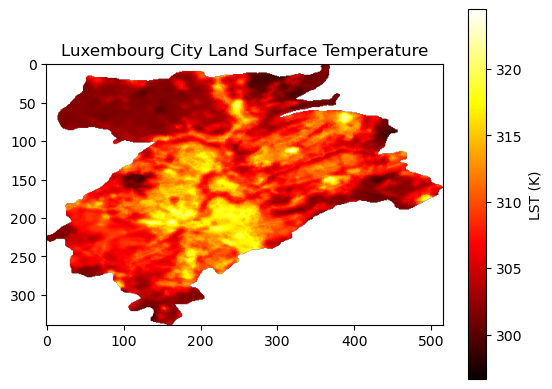

In [23]:
import matplotlib.pyplot as plt
img = gdal.Open('dataset/LUX_L8_LST_median.tif').ReadAsArray()
plt.imshow(img, cmap='hot')
plt.colorbar(label='LST (K)')
plt.title('Luxembourg City Land Surface Temperature')
plt.show()

# 2) Compute LST across Luxembourg and zonal stats (mean, max) over predefined districts/cantons (GADM level-1 or -2) to quantify urban heat intensity

In [26]:
gdf1 = gpd.read_file('dataset/gadm41_LUX_shp/gadm41_LUX_0.shp')
gdf1

,GID_0,COUNTRY,geometry
0,LUX,Luxembourg,"POLYGON ((6.29749 49.48136, 6.29562 49.48172, ..."


In [27]:
gdf1.info

<bound method DataFrame.info of   GID_0     COUNTRY                                           geometry
0   LUX  Luxembourg  POLYGON ((6.29749 49.48136, 6.29562 49.48172, ...>

In [28]:
gdf1.total_bounds

array([ 5.74414015, 49.44780731,  6.53077459, 50.18162155])

<Axes: >

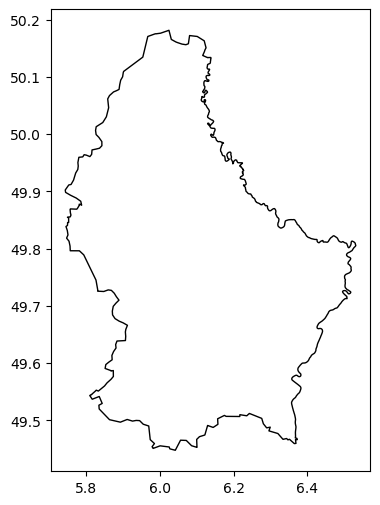

In [29]:
gdf1.plot(figsize=(6,6), edgecolor='black', facecolor='none')

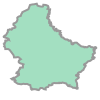

In [38]:
# Grab Lux geometry directly
lux_geom_1 = gdf1.geometry.iloc[0]
lux_geom_1

In [39]:
# Convert to GeoJSON dict for EE
lux_geom_2 = ee.Geometry(lux_geom_1.__geo_interface__)

# Build a filtered Landsat 8 ImageCollection
l8 = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .filterBounds(lux_geom_2)
    .filterDate('2024-06-01', '2024-08-31')
    .filter(ee.Filter.lt('CLOUD_COVER', 10))
)

# Select the surface temperature band (ST_B10) and take the median
thermal = l8.select('ST_B10').median()

# Clip the thermal image to Luxembourg city
clipped = thermal.clip(lux_geom_2)

# Export to Drive
task = ee.batch.Export.image.toDrive(
    image = clipped,
    description='LuxCo_L8_ST_B10_median',
    folder='EarthEngine',
    fileNamePrefix='LUXCo_L8_ST_B10_median',
    scale=30,
    crs = 'EPSG:4326',
    maxPixels=1e13
)
task.start()
print('Export task started.')

Export task started.


In [41]:
# Acquire & load Red (B4) and NIR (B5) bands

# Select the surface reflectance bands (SR_B4 and SR_B5) and take the median image
reflectance3 = l8.select('SR_B4').median()
reflectance4 = l8.select('SR_B5').median()

# Clip the thermal image to Luxembourg city
clipped3 = reflectance3.clip(lux_geom_2)
clipped4 = reflectance4.clip(lux_geom_2)

# Visualize in the EE code editor or export to Drive
task3 = ee.batch.Export.image.toDrive(
    image = clipped3,
    description='LuxCo_L8_SR_B4_median',
    folder='EarthEngine',
    fileNamePrefix='LUXCo_L8_SR_B4_median',
    scale=30,
    crs = 'EPSG:4326',
    maxPixels=1e13
)
task3.start()

task4 = ee.batch.Export.image.toDrive(
    image = clipped4,
    description='LuxCo_L8_SR_B5_median',
    folder='EarthEngine',
    fileNamePrefix='LUXCo_L8_SR_B5_median',
    scale=30,
    crs = 'EPSG:4326',
    maxPixels=1e13
)
task4.start()

print('Export tasks started.')

Export tasks started.


In [43]:
# Brightness temperature (Kelvin)
bt1, gt1, proj1 = read_tif('dataset/LUXCo_L8_ST_B10_median.tif')
bt1 = bt1 * 0.00341802 + 149.0    # apply EE scale + offset

# Surface reflectance bands (divide by 1e4 if needed)
red1, _, _ = read_tif('dataset/LUXCo_L8_SR_B4_median.tif')
red1 = red1*0.0000275 - 0.2
nir1, _, _ = read_tif('dataset/LUXCo_L8_SR_B5_median.tif')
nir1 = nir1*0.0000275 - 0.2

# NDVI
ndvi1 = (nir1 - red1) / (nir1 + red1 + 1e-6)

# Emissivity ε (simple two‐threshold model)
em1 = np.where(
    ndvi1 < 0.2, 
    0.97, 
    np.where(
        ndvi1 > 0.5,
        0.99,
        0.97 + ((ndvi1 - 0.2) * (0.99 - 0.97) / (0.5 - 0.2))
    )
)
lst1 = bt1 / (1 + (wavelength * bt1 / rho) * np.log(em1))

# Setup output raster
rows, cols = lst1.shape
driver1 = gdal.GetDriverByName('GTiff')
out = driver1.Create('dataset/LUXCo_L8_LST_median.tif', cols, rows, 1, gdal.GDT_Float32)
out.SetGeoTransform(gt1)
out.SetProjection(proj1)
out.GetRasterBand(1).WriteArray(lst1)

# 5. Flush & close
out.FlushCache()
out = None

print("LST GeoTIFF written: LUXCo_L8_LST_median.tif")

LST GeoTIFF written: LUXCo_L8_LST_median.tif


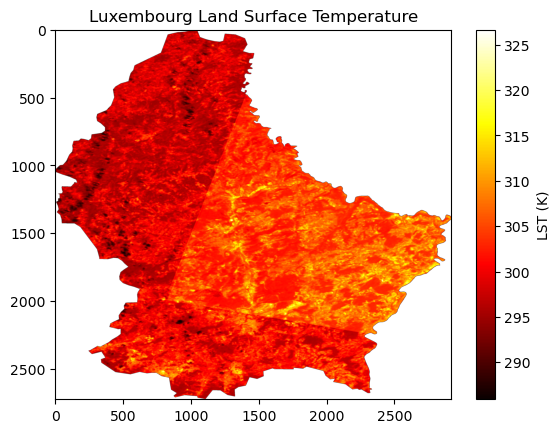

In [44]:
# Visualize
img = gdal.Open('dataset/LUXCo_L8_LST_median.tif').ReadAsArray()
plt.imshow(img, cmap='hot')
plt.colorbar(label='LST (K)')
plt.title('Luxembourg Land Surface Temperature')
plt.show()

In [46]:
from rasterstats import zonal_stats

## Compute zonal stats over districts

In [48]:
# Read GADM level-1 (districts) or level-2 (cantons)
# Make sure it’s in the same CRS as the LST GeoTIFF
districts = gpd.read_file('dataset/gadm41_LUX_shp/gadm41_LUX_1.shp').to_crs('EPSG:4326')
districts

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,LUX.1_1,LUX,Luxembourg,Diekirch,Dikrech|Dikkrich,NA,District,District,NA,LU.DI,LU-DI,"POLYGON ((5.86046 49.72802, 5.85199 49.72604, ..."
1,LUX.2_1,LUX,Luxembourg,Grevenmacher,Gréivemaacher,NA,District,District,NA,LU.GR,LU-GR,"POLYGON ((6.32387 49.47416, 6.31986 49.4771, 6..."
2,LUX.3_1,LUX,Luxembourg,Luxembourg,Lëtzebuerg|Luxemburg,NA,District,District,NA,LU.LU,LU-LU,"POLYGON ((6.07187 49.46503, 6.05634 49.4654, 6..."


In [50]:
# Path to the LST raster
rst_path = 'dataset/LUXCo_L8_LST_median.tif'

# Compute zonal stats, mean and max of LST within each polygon
stats = zonal_stats(
    vectors=districts,
    raster=rst_path,
    stats=['mean','max'],
    nodata=-999,
    geojson_out=False
)

# Append results back to your GeoDataFrame
districts['mean_LST'] = [s['mean'] for s in stats]
districts['max_LST']  = [s['max']  for s in stats]

print(districts[['NAME_1','mean_LST','max_LST']])
# Save as a new shapefile/GeoJSON with attributes
districts.to_file('lux_l1_lst_stats.geojson', driver='GeoJSON')

         NAME_1    mean_LST     max_LST
0      Diekirch  299.218243  320.250488
1  Grevenmacher  305.650005  326.650635
2    Luxembourg  302.538851  325.262238


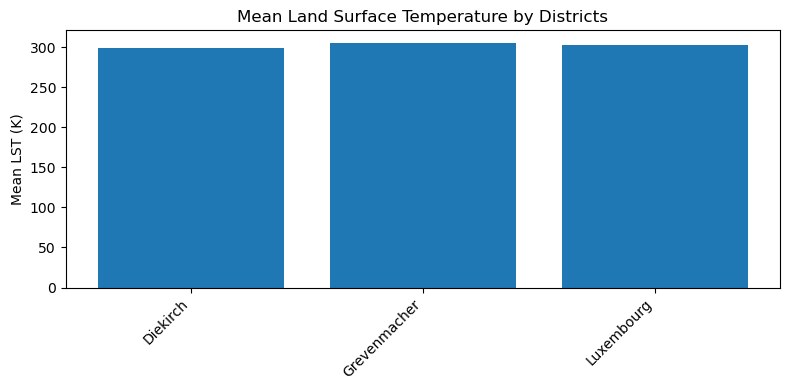

In [51]:
# Plot Bar Chart
# Sort by descending mean, then plot
df = districts.sort_values('mean_LST', ascending=False)
plt.figure(figsize=(8,4))
plt.bar(districts['NAME_1'], districts['mean_LST'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean LST (K)')
plt.title('Mean Land Surface Temperature by Districts')
plt.tight_layout()
plt.show()

## Cantons

              NAME_2    mean_LST     max_LST
0           Clervaux  298.253648  319.156982
1           Diekirch  303.402333  320.250488
2            Redange  297.782073  310.524353
3            Vianden  303.818521  315.684967
4              Wiltz  297.217197  312.204041
5         Echternach  306.173354  325.109497
6       Grevenmacher  307.061695  326.650635
7             Remich  302.542004  317.310669
8           Capellen  300.685957  324.027405
9   Esch-sur-Alzette  300.971368  322.897491
10        Luxembourg  303.842851  325.262238
11            Mersch  304.368795  325.163330


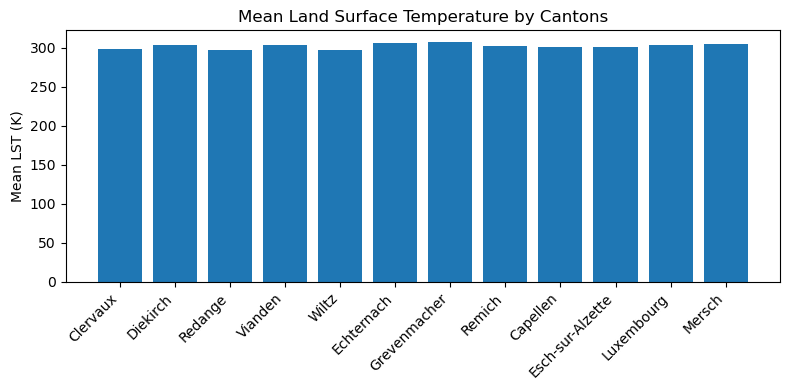

In [52]:
# Read GADM level-2 (Cantons)
cantons = gpd.read_file('dataset/gadm41_LUX_shp/gadm41_LUX_2.shp').to_crs('EPSG:4326')

# Compute zonal stats, mean and max of LST within each polygon
stats = zonal_stats(
    vectors=cantons,
    raster=rst_path,
    stats=['mean','max'],
    nodata=-999,
    geojson_out=False
)

# Append results back to your GeoDataFrame
cantons['mean_LST'] = [s['mean'] for s in stats]
cantons['max_LST']  = [s['max']  for s in stats]

print(cantons[['NAME_2','mean_LST','max_LST']])

# Plot Bar Chart
df = cantons.sort_values('mean_LST', ascending=False)
plt.figure(figsize=(8,4))
plt.bar(cantons['NAME_2'], cantons['mean_LST'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean LST (K)')
plt.title('Mean Land Surface Temperature by Cantons')
plt.tight_layout()
plt.show()

## Compute urban-rural (e.g., Luxembourg-Wiltz) LST difference

In [55]:
urb_mean = cantons['mean_LST'][10]
rur_mean = cantons['mean_LST'][4]
delta_mean = urb_mean - rur_mean
print(urb_mean)
print(rur_mean)
print("Mean Urban–Rural LST Difference:", round(delta_mean,2), "K")

303.8428514804684
297.21719701293233
Mean Urban–Rural LST Difference: 6.63 K


This outcome indicates that the canton Luxembourg is on average 6.63 K hotter than the rural (canton Wiltz) reference, revealing the strength of the urban heat island.